In [25]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras as keras
import os

In [26]:
DATASET = './dataset/Boot'
images = []
for idx, filename in enumerate(os.listdir(DATASET)):
    img=  tf.keras.preprocessing.image.load_img(os.path.join(DATASET, filename),target_size=(102,136))
    img= tf.keras.preprocessing.image.img_to_array(img)
    images.append(img)
    if idx >2000:
        break

In [27]:
images =np.asarray(images).astype(np.float32) /255.0
x_train = images[:-10]
x_test  = images[-10:]
BATCH_SIZE = 20
IMAGE_ORIGINAL_SIZE= x_train.shape[1:]
IMAGE_SIZE = IMAGE_ORIGINAL_SIZE[0]*IMAGE_ORIGINAL_SIZE[1]*IMAGE_ORIGINAL_SIZE[2]
HIDDEN_DIMENSION = 512
LATENT_DIMENSION =32
MAX_EPOCHS = 10
LEARNING_RATE= 0.0001

In [28]:
# building the model
class VAE(tf.keras.Model):
    def __init__(self, dim, **kwargs):
        super(VAE, self).__init__(**kwargs)
        dim_h = dim[0]
        dim_z = dim[1]

        self.fc1 = tf.keras.layers.Dense(dim_h, activation=tf.nn.relu)
        self.fc2 = tf.keras.layers.Dense(dim_z)
        self.fc3 = tf.keras.layers.Dense(dim_z)
        self.fc4 = tf.keras.layers.Dense(dim_h)
        self.fc5 = tf.keras.layers.Dense(IMAGE_SIZE)

        self.encode_batch_norm = tf.keras.layers.BatchNormalization()
        self.decode_batch_norm = tf.keras.layers.BatchNormalization()

    def encode(self, x):
        x = self.encode_batch_norm(x)
        h = self.fc1(x)
        return self.fc2(h), self.fc3(h)
    
    def decode_logit(self, z):
        h = self.fc4(z)
        h = self.fc5(h)
        return self.decode_batch_norm(h)
    
    def decode(self, z):
        return tf.nn.sigmoid(self.decode_logit(z))
    
    def reparameterize(self, mu, log_var):
        std = tf.exp(0.5 * log_var)
        eps = tf.random.normal(std.shape)
        return mu + std * eps
    
    def call(self, input, training=None, mask=None):
        mu, log_var = self.encode(input)
        z = self.reparameterize(mu, log_var)
        x_recon_logit = self.decode_logit(z)
        return x_recon_logit, mu, log_var

In [29]:
# applying the model
model = VAE((HIDDEN_DIMENSION, LATENT_DIMENSION))
model.build(input_shape=(BATCH_SIZE, IMAGE_SIZE))
print(model.summary())

c:\Github\deep-learning\venv\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'vae_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "vae_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
# set optimizer and dataset
optimizers = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BATCH_SIZE*5).batch(BATCH_SIZE)

In [31]:
# epoch to get loss and KL div
loss_history = []
kl_div_history = []

num_batches = x_train.shape[0] // BATCH_SIZE

for epoch in range(MAX_EPOCHS):
    for x in dataset:
        x = tf.reshape(x, [-1, IMAGE_SIZE])
        with tf.GradientTape() as tape:
            x_recon_logit, mu, log_var = model(x)
            recon = tf.nn.sigmoid_cross_entropy_with_logits(labels=x, logits=x_recon_logit)
            recon_loss = tf.reduce_sum(recon) / BATCH_SIZE

            kl_div = -0.5 * tf.reduce_sum(1. + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
            kl_div = tf.reduce_mean(kl_div)
            loss = tf.reduce_mean(recon_loss + kl_div)

        gradients = tape.gradient(loss, model.trainable_variables)

        for g in gradients:
            tf.clip_by_norm(g, 15)
        
        optimizers.apply_gradients(zip(gradients, model.trainable_variables))

    loss_history.append(loss)
    kl_div_history.append(kl_div)
    print(f"Epoch: {epoch}/{MAX_EPOCHS}, Recon loss: {recon_loss}, kl div: {kl_div}, loss: {loss}")

Epoch: 0/10, Recon loss: 6801.87109375, kl div: 655.3619995117188, loss: 7457.23291015625
Epoch: 1/10, Recon loss: 7137.6435546875, kl div: 474.6580505371094, loss: 7612.3017578125
Epoch: 2/10, Recon loss: 6536.6123046875, kl div: 407.0603332519531, loss: 6943.6728515625
Epoch: 3/10, Recon loss: 6678.82275390625, kl div: 307.9219970703125, loss: 6986.74462890625
Epoch: 4/10, Recon loss: 7379.7021484375, kl div: 236.3334503173828, loss: 7616.03564453125
Epoch: 5/10, Recon loss: 6508.5498046875, kl div: 240.83827209472656, loss: 6749.38818359375
Epoch: 6/10, Recon loss: 6757.91943359375, kl div: 239.2894287109375, loss: 6997.208984375
Epoch: 7/10, Recon loss: 6990.64990234375, kl div: 259.60296630859375, loss: 7250.2529296875
Epoch: 8/10, Recon loss: 5845.2138671875, kl div: 240.0125732421875, loss: 6085.2265625
Epoch: 9/10, Recon loss: 6696.58349609375, kl div: 179.989013671875, loss: 6876.572265625


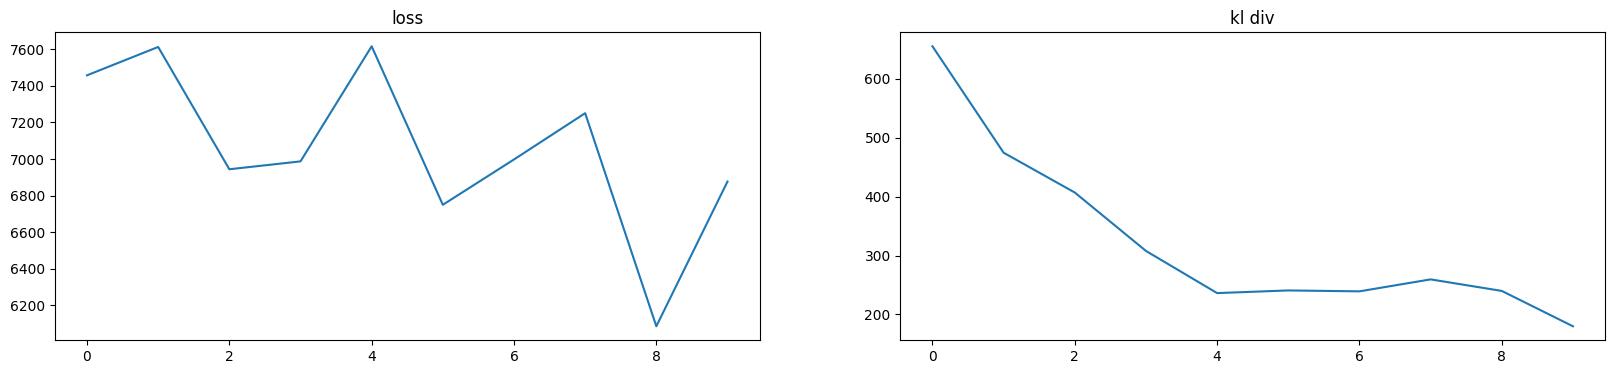

In [32]:
# plot loss and kl div
plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 1)
plt.title('loss')
plt.plot(loss_history)

plt.subplot(1, 2, 2)
plt.title('kl div')
plt.plot(kl_div_history)

In [33]:
# decode to image
def get_out_from_z(z):
    out = model.decode(z)
    out = tf.reshape(out, (-1, IMAGE_ORIGINAL_SIZE[0], IMAGE_ORIGINAL_SIZE[1], IMAGE_ORIGINAL_SIZE[2]))
    return out

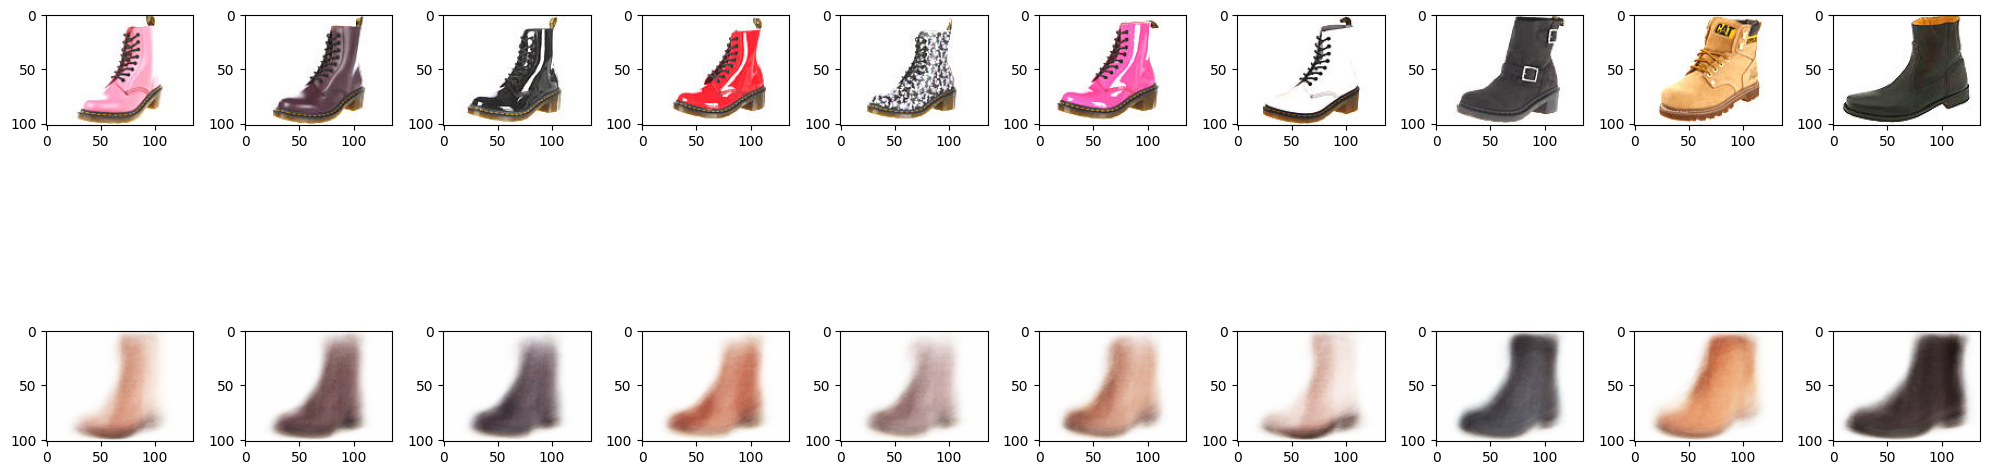

In [34]:
# display result
mu, log_var = model.encode(x_test.reshape(-1, IMAGE_SIZE))
z = model.reparameterize(mu, log_var)
out = get_out_from_z(z)

number = 10
plt.figure(figsize=(20, 8))
for idx in range(number):
    ax = plt.subplot(2, number, idx + 1)
    plt.imshow(x_test[idx].reshape(IMAGE_ORIGINAL_SIZE), cmap='gray')

for idx in range(number):
    ax = plt.subplot(2, number, number + idx + 1)
    plt.imshow(out[idx].numpy(), cmap='gray')

plt.tight_layout()
plt.show()